In [1]:
from robolib.DoublePendulum import DoublePendulum
import spatialmath as sm
from tqdm import tqdm 
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')


In [2]:
dp = DoublePendulum()

# Actualizo algunos términos de la dinámica
dp.links[0].Jm = 1E-4
dp.links[1].Jm = 1E-4
dp.links[0].B = 0.01
dp.links[1].B = 0.01
dp.links[0].G = 10
dp.links[1].G = 10

print(dp)
print(dp.dynamics())

# Determino una trayectoria de referencia
q_dest = np.array([[-np.pi/2, 0.0],[0,np.pi/4],[0,-np.pi/4],[0,0],[0,0]]) 
Tj = np.array([1, 0.5,1,1,1 ])  
POSES_dest = dp.fkine(q_dest)

# Trayectoria JOINT
dp.jtraj(q_dest,Tj);
# Trayectoria CARTESIANA
#dp.ctraj(POSES_dest,Tj);


DHRobot: DoublePendulum, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬─────────┬───────┬────────┬─────┐
│   j   │  m   │      r       │              I              │   Jm    │   B   │   Tc   │  G  │
├───────┼──────┼──────────────┼─────────────────────────────┼─────────┼───────┼────────┼─────┤
│ link1 │  1   │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  0.0001 │  0.01 │  0,  0 │  10 │
│ link2 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  0.0001 │  0.01 │  0,  0 │  10 │
└───────┴──────┴──────────────┴─────────────────────────────┴─────────┴───────┴────────┴─────┘

None


In [10]:
def smc_controller(robot, t, q, qd,
                   Lambda=np.diag([6,6]), K=np.diag([15,15]), phi=0.05):

    _,q_ref,qd_ref,qdd_ref = dp.get_control_ref(t)
    e  = q - q_ref
    ed = qd - qd_ref
    s  = ed + Lambda @ e

    M = robot.inertia(q)
    C = robot.coriolis(q, qd)
    G = robot.gravload(q)

    # Control equivalente (inverse dynamics)
    tau_eq = M @ (qdd_ref - Lambda @ ed) + C @ (qd_ref - Lambda @ e) + G

    # Término de conmutación suavizado (tanh)
    tau_sw = K @ np.tanh(s / phi)

    tau = tau_eq - tau_sw        
    return tau

#tg = dp.nofriction(coulomb=True, viscous=False).fdyn(dp.t_ref[-1], 
#                                                          dp.q_ref[0],
#                                                          Q=smc_controller,                                                          
#                                                          qd0=dp.qd_ref[0],
#                                                          dt=dp.Ts,
#                                                          solver_args={'rtol': 1e-6},
#                                                          progress=True)


t,q,qd,u = dp.sim_dis_control(smc_controller,solver_kwargs = {'rtol': 1e-6})

100%|██████████| 3699/3699 [00:26<00:00, 140.38it/s]


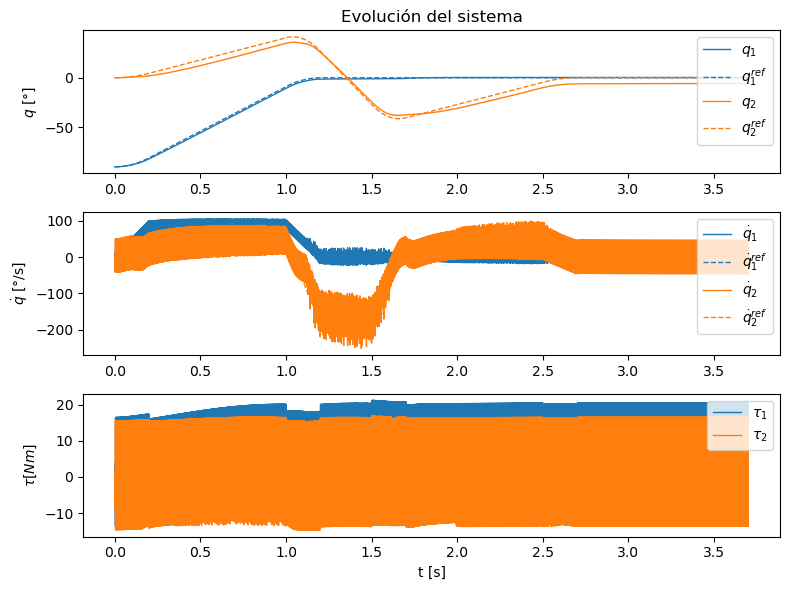

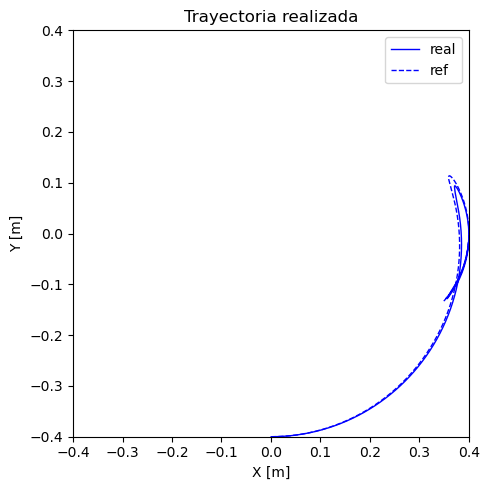

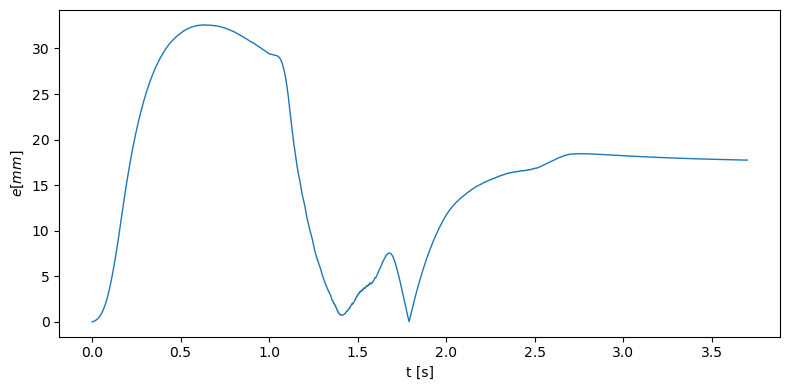

In [11]:
dp.plot_sim(dp.t_ref,q,qd,dp.t_ref,u)

In [7]:


# Determino una trayectoria de referencia
N_segments = 3
q_dest = (np.random.rand(N_segments, dp.n))*np.pi
POSES_dest = dp.fkine(q_dest)
Tj = np.random.rand(N_segments, )+2

# Trayectoria JOINT
#dp.genTrJoint(q_dest,Tj)
# Trayectoria CARTESIANA
dp.genTrCart(POSES_dest,Tj)

# Agrego carga e incertezas en el modelo
#dp.payload(1, [0.0, 0.0, 0.0])
dp_real = dp.perturb(0.5)


# Parámetros del solver RK45
solver_kwargs = {
    'rtol': 1e-6     # Tolerancia relativa
#    'atol': 1e-8     # Tolerancia absoluta
#    'max_step': 0.1   # Tamaño máximo del paso de integración
}


def control(robot, t, q, qd, dp):
  _,q_ref,qd_ref,qdd_ref = dp.getControlReference(t)

  # Calculo la acción de control
  Kp = np.array([30,10])
  Kd = np.array([1,1])
  # El lazo se resuelve con PD
  ufb = Kp * (q_ref-q) + Kd * (qd_ref-qd)
  # La acción FF es con el modelo completo
  uff = dp.rne(q_ref,qd_ref,qdd_ref)
  # La acción es PD+FF
  u = ufb #+ uff
  return u


# Simulación
torque = np.zeros_like(dp.q_ref)

t_fin = dp.t_ref[-1]
q_ini = dp.q_ref[0]
qd_ini = dp.qd_ref[0]
tg = dp_real.nofriction(coulomb=True, viscous=False).fdyn(t_fin, 
                                                          q_ini,
                                                          Q=control,
                                                          Q_args={'dp': dp},
                                                          qd0=qd_ini,
                                                          dt=dp.Ts,
                                                          solver_args=solver_kwargs,
                                                          progress=True)





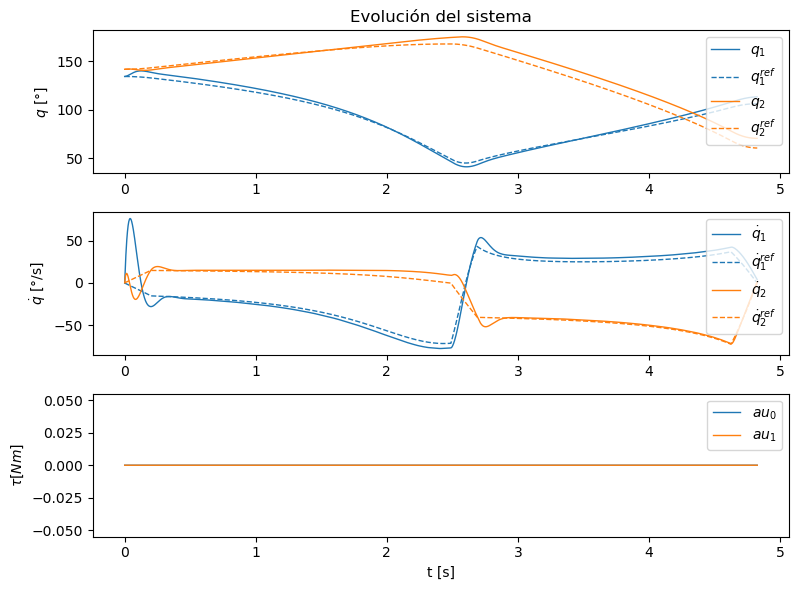

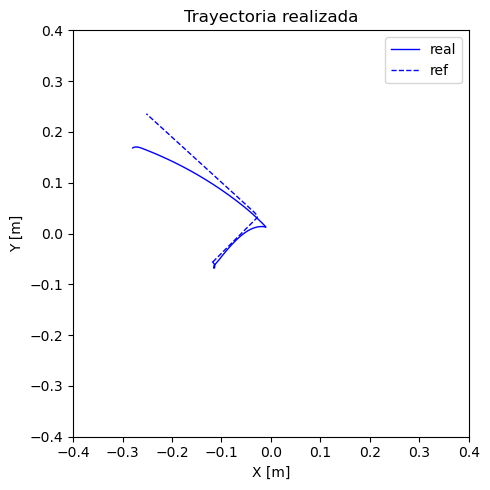

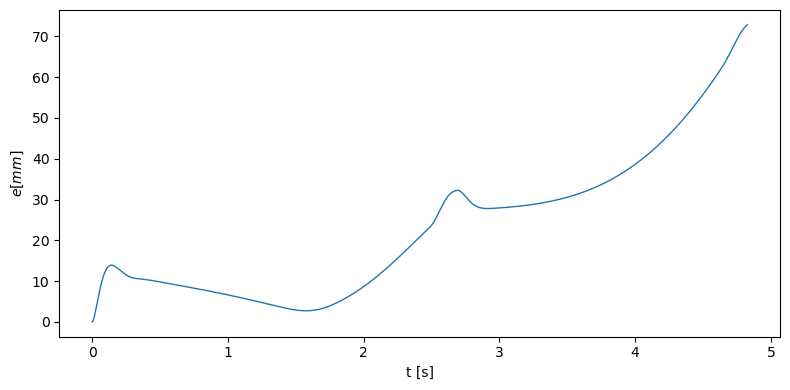

In [8]:
dp.curvePlot(tg.t,tg.q,tg.qd,dp.t_ref,torque)